In [1]:
source("src/functions_and_things.r")

load_libraries()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 


Warning message:
“package ‘zoo’ was built under R version 4.5.2”

Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




In [3]:
df <- read.csv("data/processed/combined_data_daily.csv")

head(df)

,date,borough,coords_cbd,ridership,min_temp,snow,rain,unemp.x,month,unemp.y,unemp
,<chr>,<chr>,<lgl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
1,2024-06-01,Bronx,FALSE,140211,62,0,0,4.7,2024-06-01,4.7,4.7
2,2024-06-01,Brooklyn,FALSE,501778,62,0,0,4.7,2024-06-01,4.7,4.7
3,2024-06-01,Brooklyn,TRUE,20848,62,0,0,4.7,2024-06-01,4.7,4.7
4,2024-06-01,Manhattan,FALSE,383193,62,0,0,4.7,2024-06-01,4.7,4.7
5,2024-06-01,Manhattan,TRUE,575531,62,0,0,4.7,2024-06-01,4.7,4.7
6,2024-06-01,Queens,FALSE,345374,62,0,0,4.7,2024-06-01,4.7,4.7


## Can i explain variation in ridership? 

In [28]:
row = which.min(df_brooklyn$ridership)
print(df_brooklyn[row, ])

df <- df[-row, ]

          date  borough coords_cbd ridership min_temp snow rain unemp.x
732 2025-06-01 Brooklyn       TRUE       232       52    0    0     4.5
         month unemp.y unemp
732 2025-06-01     4.5   4.5


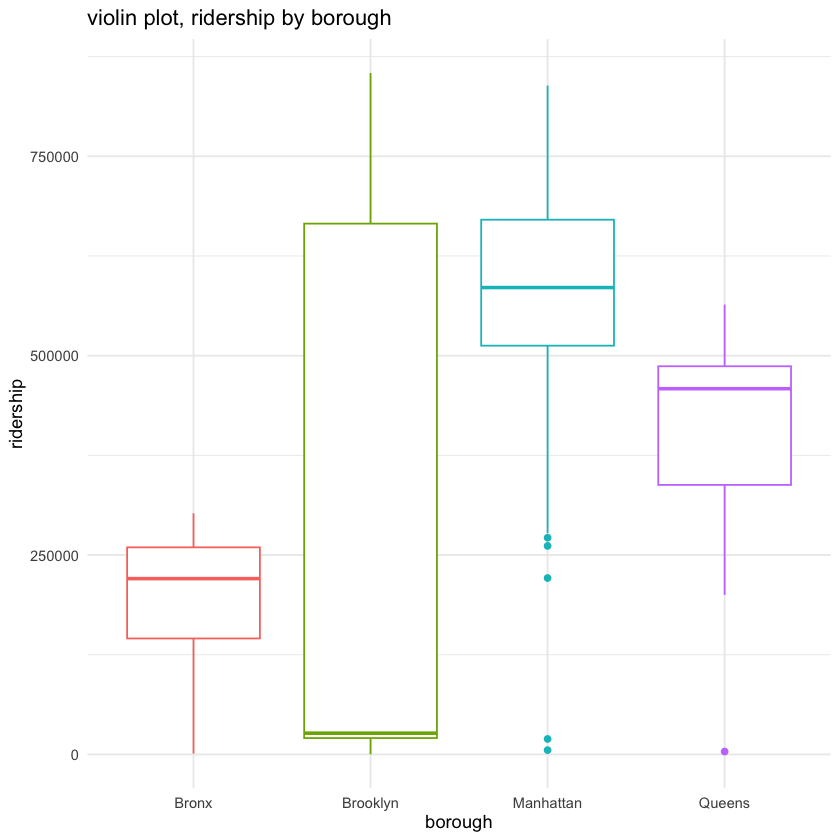

In [29]:
ggplot(data = df, aes(x = borough, y = ridership, color = borough)) + 
    geom_boxplot() + theme_minimal() + 
    labs(title = "violin plot, ridership by borough") + 
    theme(legend.position = "none")

## Models maybe

In [50]:
summary(df)

     date             borough          coords_cbd        ridership     
 Length:2195        Length:2195        Mode :logical   Min.   :   232  
 Class :character   Class :character   FALSE:1463      1st Qu.:219638  
 Mode  :character   Mode  :character   TRUE :732       Median :455240  
                                                       Mean   :407674  
                                                       3rd Qu.:613580  
                                                       Max.   :854376  
                                                                       
    min_temp          snow              rain            unemp.x     
 Min.   :12.00   Min.   :0.00000   Min.   :0.00000   Min.   :4.000  
 1st Qu.:38.00   1st Qu.:0.00000   1st Qu.:0.00000   1st Qu.:4.300  
 Median :50.00   Median :0.00000   Median :0.00000   Median :4.500  
 Mean   :49.48   Mean   :0.05646   Mean   :0.08938   Mean   :4.515  
 3rd Qu.:63.00   3rd Qu.:0.00000   3rd Qu.:0.04000   3rd Qu.:4.700  
 Max.   :7

In [72]:
df$rain[is.na(df$rain)] <- 0 
df$date[is.na(df$date)] <- 0 

df$ridership = as.numeric(df$ridership)

In [73]:
reg1 <- lm(ridership ~ min_temp, data = df)
reg2 <- lm(ridership ~ min_temp + rain, data = df)
reg3 <- lm(ridership ~ min_temp + rain + borough, data = df)

stargazer(reg1, reg2, reg3, type = "text", style = "aer")


                                                    ridership                                
                              (1)                     (2)                      (3)           
---------------------------------------------------------------------------------------------
min_temp                    171.599                 189.453                  189.833         
                           (336.441)               (336.798)                (280.983)        
                                                                                             
rain                                              -26,206.750              -26,221.820       
                                                 (23,369.050)             (19,496.300)       
                                                                                             
boroughBrooklyn                                                          118,124.100***      
                                                           

`geom_smooth()` using formula = 'y ~ x'


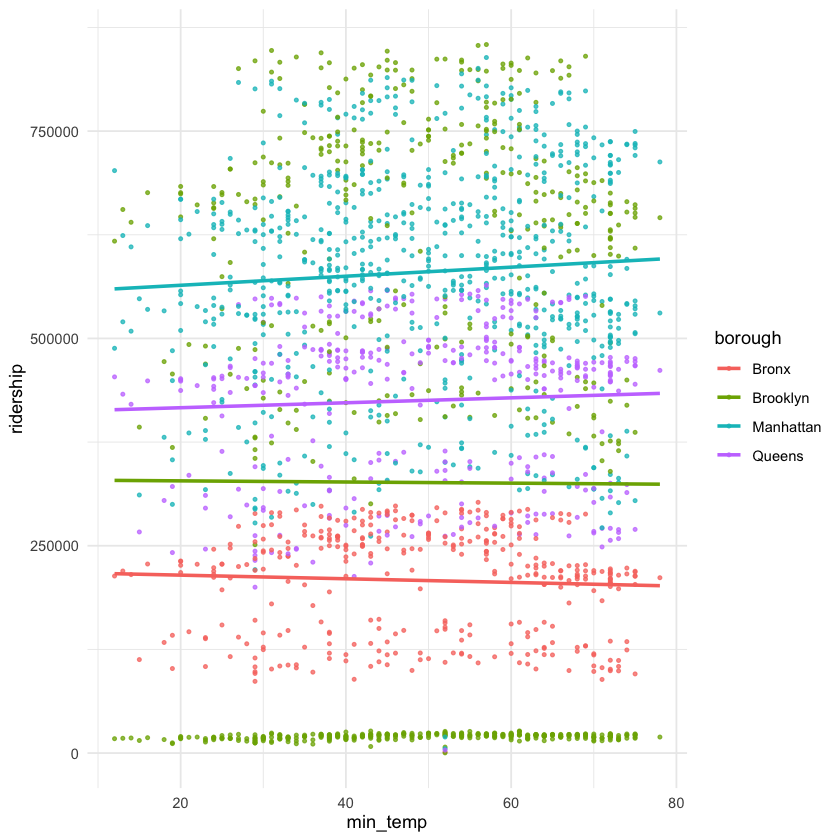

In [74]:
ggplot(data = df, aes(x = min_temp, y = ridership, color = borough)) + 
    geom_point(size = .75, alpha = .75) + theme_minimal() + 
    geom_smooth(method = "lm", se = FALSE)

## Diagnostics

### plots 

Code from the exam 2 practice problems 

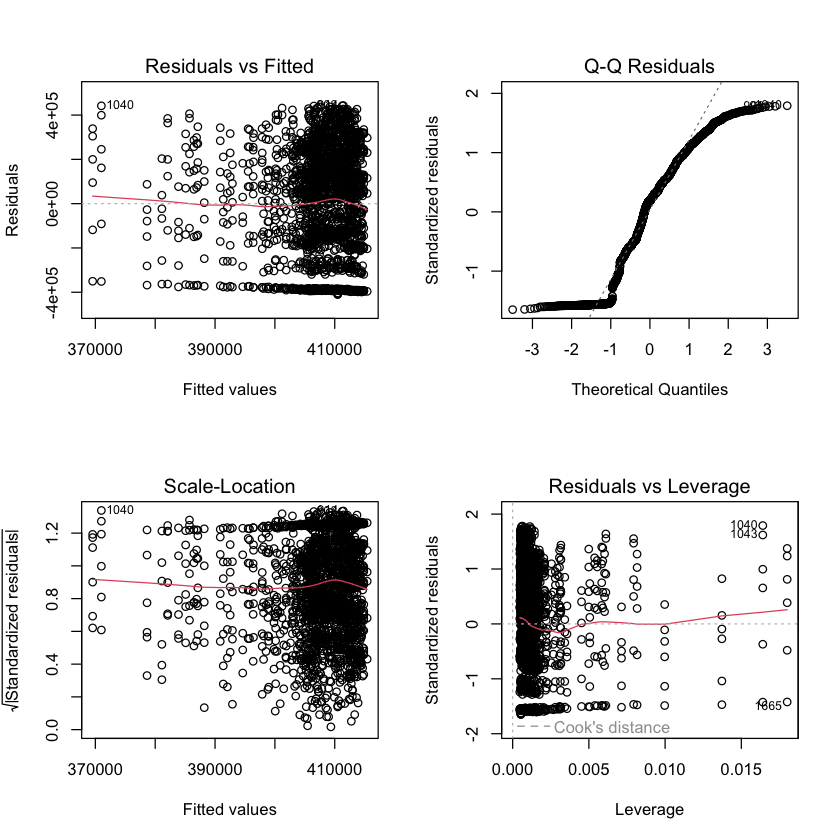

In [75]:
par(mfrow = c(2,2))
plot(reg2)

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“NAs introduced by coercion”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”


ERROR: Error in plot.window(...): need finite 'xlim' values


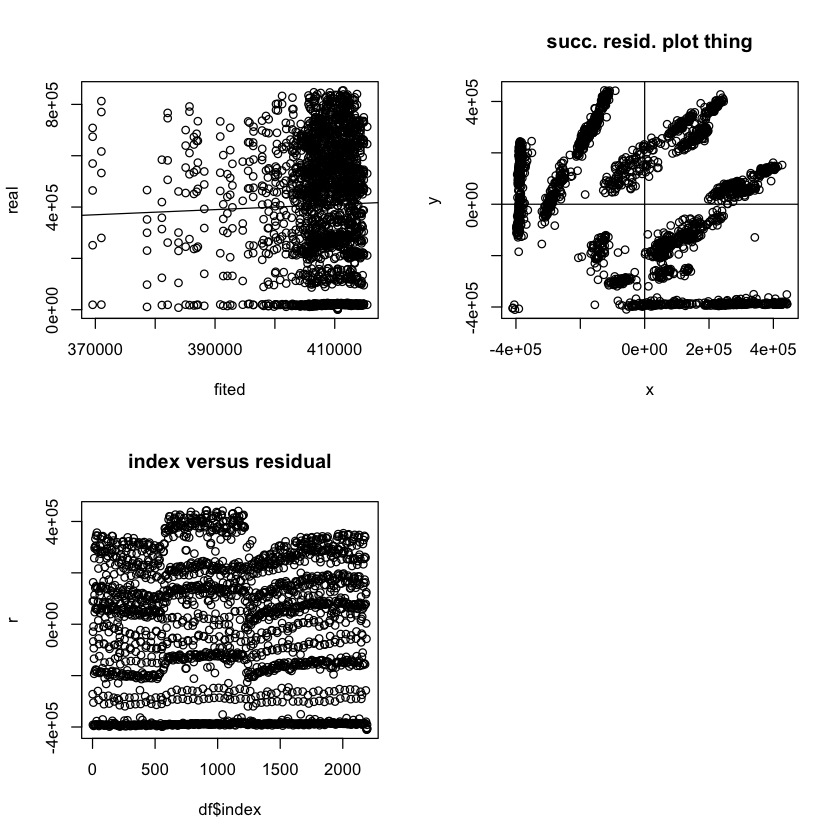

In [77]:
par(mfrow = c(2,2))

plot(fitted(reg2), df$ridership, xlab = "fited", ylab = "real")
abline(0, 1)

n = dim(df)[1]
r = resid(reg2) 
x = head(r, n-1)
y = tail(r, n-1)

plot(x, y, main = "succ. resid. plot thing")
abline(v = mean(r), h = mean(r))

df$index = c(1:n)

plot(df$index, r, main = "index versus residual")
plot(df$date, r, main = "date versus residual")